# Student Performance Analysis Using Statistical Modeling

## Exploratory Data Analysis, Hypothesis Testing & Multiple Linear Regression in Python

This project explores the factors associated with student academic performance using exploratory data analysis, hypothesis testing, and statistical modeling techniques in Python.

The analysis focuses on identifying which academic, behavioral, and socio-economic factors appear most strongly associated with exam performance while applying rigorous statistical reasoning and model diagnostics.

## Research Questions

This project aims to explore the following questions:

- Does attendance significantly impact exam performance?
- Are highly motivated students more likely to achieve top grades?
- Which factors appear most strongly associated with academic success?
- Does parental involvement influence academic outcomes?

## Methodology

The analysis followed a structured workflow combining exploratory analysis, inferential statistics, and multivariate modeling techniques:

1. Data quality validation
2. Exploratory data analysis (EDA)
3. Correlation analysis
4. Group comparison analysis
5. Hypothesis testing using ANOVA
6. Interpretation of statistically significant relationships

## Import Libraries
The following libraries were used throughout the analysis for data manipulation, visualization, statistical testing, and regression modeling.

In [84]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import f_oneway
import statsmodels as sm
from sklearn.impute import SimpleImputer
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

## Import the Data

The dataset was imported using pandas and preliminary inspections were performed to validate the structure and variable types.

In [85]:
df = pd.read_csv('StudentPerformanceFactors.csv')

A preliminary inspection of the dataset was performed to better understand the structure and available variables.

In [97]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


The dataset contains both numerical and categorical variables with no major structural inconsistencies detected.

### Statistical Considerations

- Statistical significance does not necessarily imply strong practical significance.
- Correlation does not imply causation.
- The dataset may not fully represent real-world educational systems.
- Some relationships may be influenced by interactions between variables not explored in this analysis.

## Data Quality Validation

We exploring the columns, the variables types and the Non-Null observation. 

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

The dataset contains both numerical and categorical variables with no major structural inconsistencies detected.

In [88]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

Only fewer missing values were identified in the dataset, suggesting that no imputation or deletion procedures were required.

In [89]:
df.duplicated().sum()

np.int64(0)

No duplicated observations were identified in the dataset, suggesting that each student record is unique and that duplicate-related data quality issues are unlikely to affect the analysis.

## Exploratory Data Analysis

We first explore the numerical variables to better understand
their distributions, central tendencies, and possible outliers.

In [90]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


A preliminary data validation check identified exam scores exceeding 100, which may represent data entry anomalies or grading adjustments such as bonus points. Since exam scores are generally expected to fall between 0 and 100, these observations were flagged for further review.

In [91]:
df[df['Exam_Score'] > 100]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101


Only one observation shows exam score exceeding 100. Leaving this observation as it is would have no impact on the analysis outcome.

We now explore the categorical variables and their frequencies, adding bar chart for visualisation

In [92]:
for col in df.select_dtypes(include='object').columns:
    print("\n", col)
    print(pd.concat(
        [df[col].value_counts(),
         round(df[col].value_counts(normalize=True)*100,2)],
        axis=1,
        keys=['Count', 'Percentage']
    ))


 Parental_Involvement
                      Count  Percentage
Parental_Involvement                   
Medium                 3362       50.89
High                   1908       28.88
Low                    1337       20.24

 Access_to_Resources
                     Count  Percentage
Access_to_Resources                   
Medium                3319       50.23
High                  1975       29.89
Low                   1313       19.87

 Extracurricular_Activities
                            Count  Percentage
Extracurricular_Activities                   
Yes                          3938        59.6
No                           2669        40.4

 Motivation_Level
                  Count  Percentage
Motivation_Level                   
Medium             3351       50.72
Low                1937       29.32
High               1319       19.96

 Internet_Access
                 Count  Percentage
Internet_Access                   
Yes               6108       92.45
No                 499   

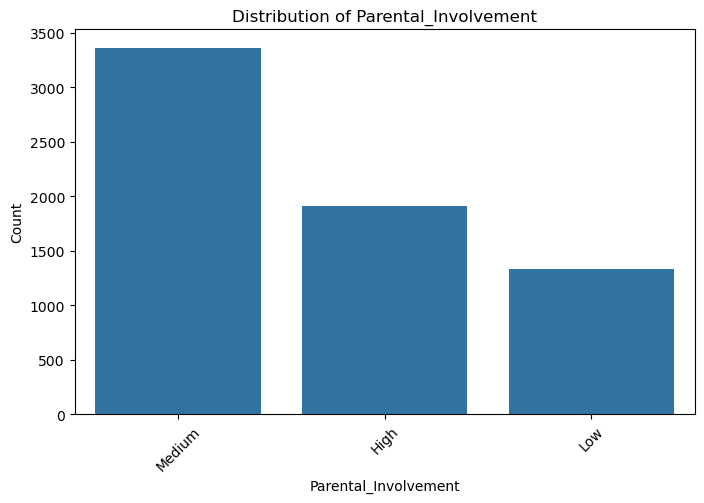

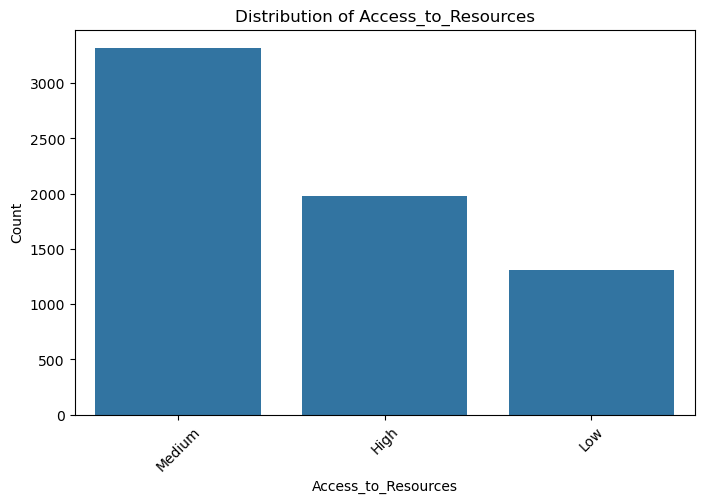

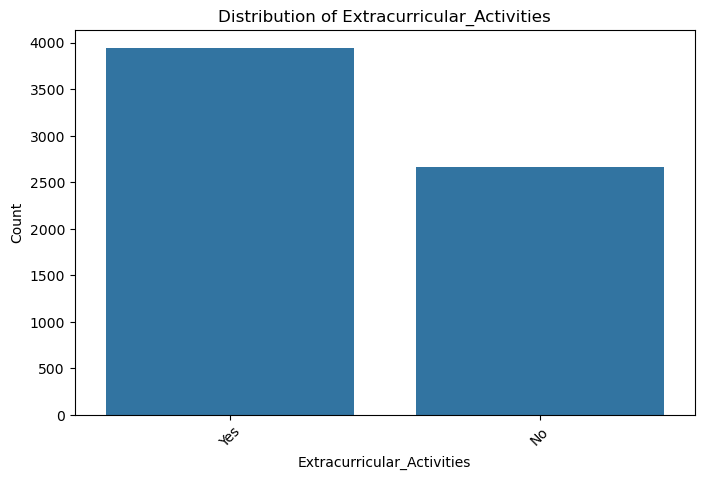

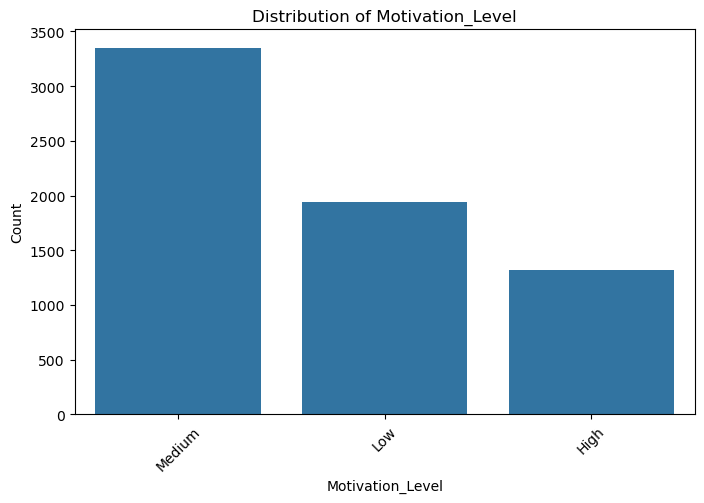

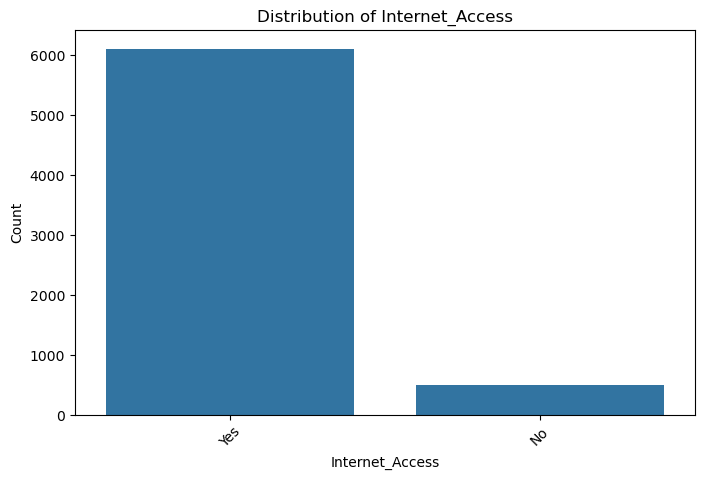

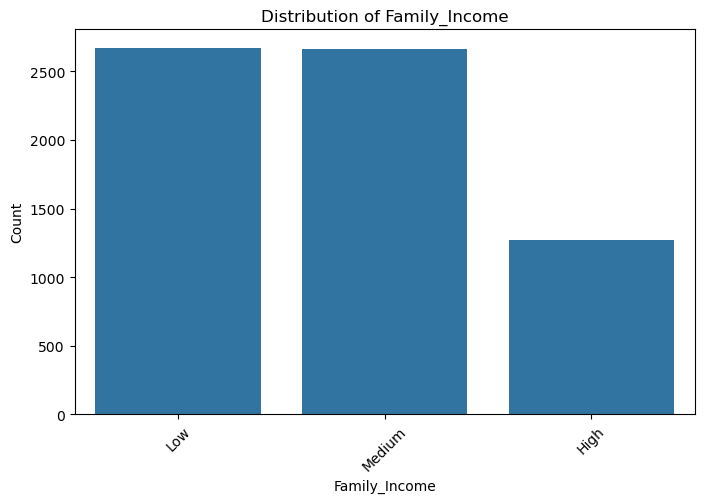

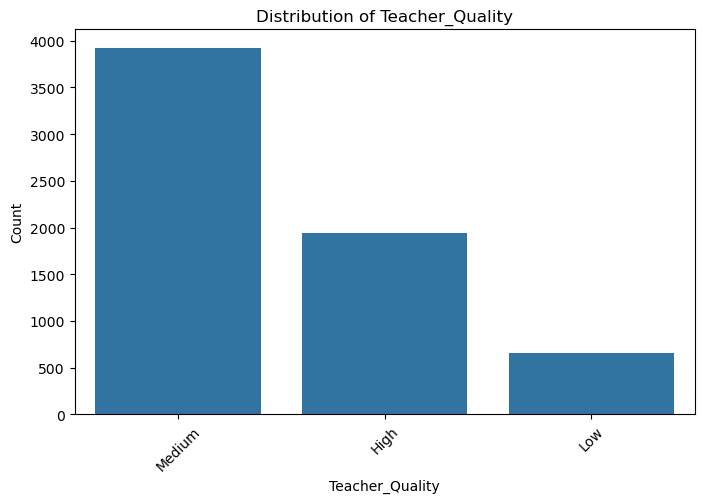

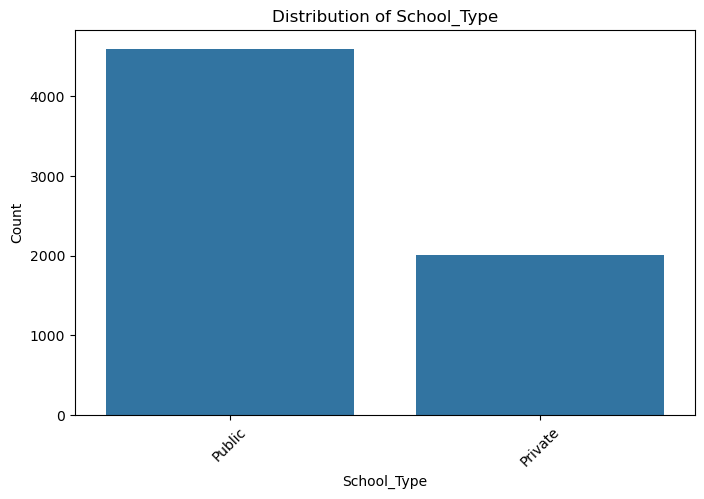

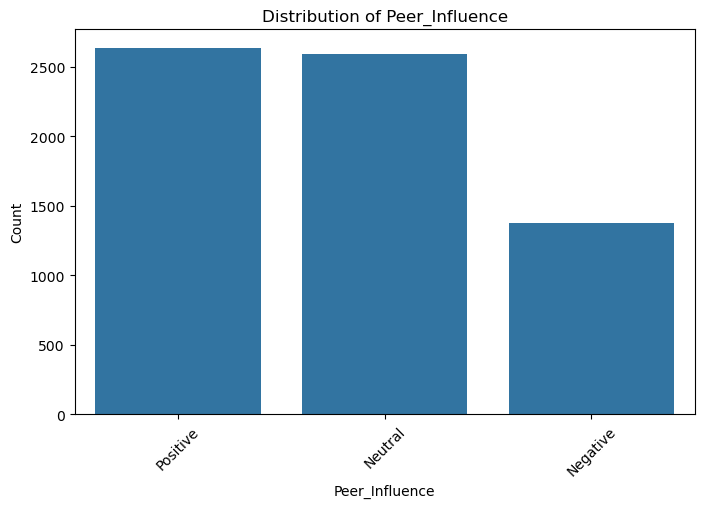

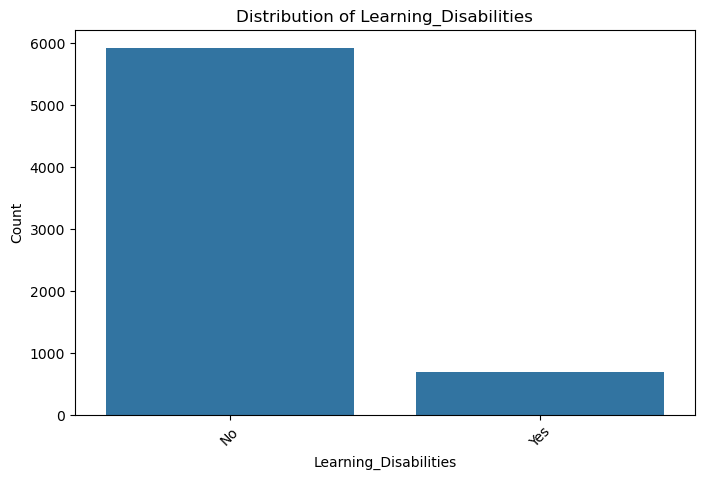

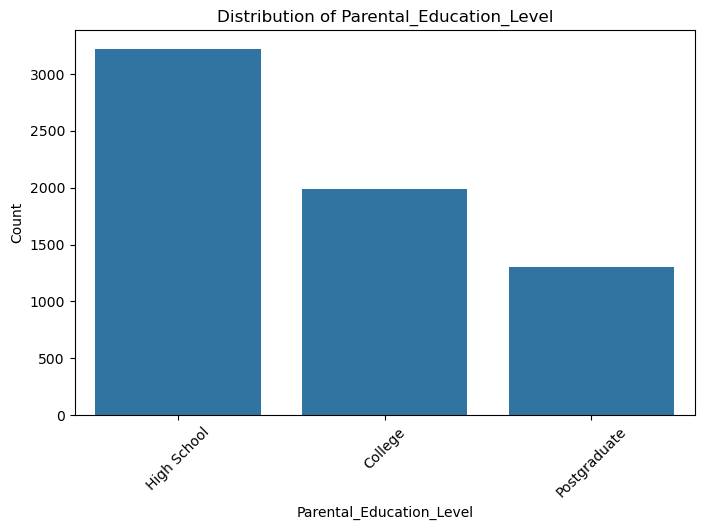

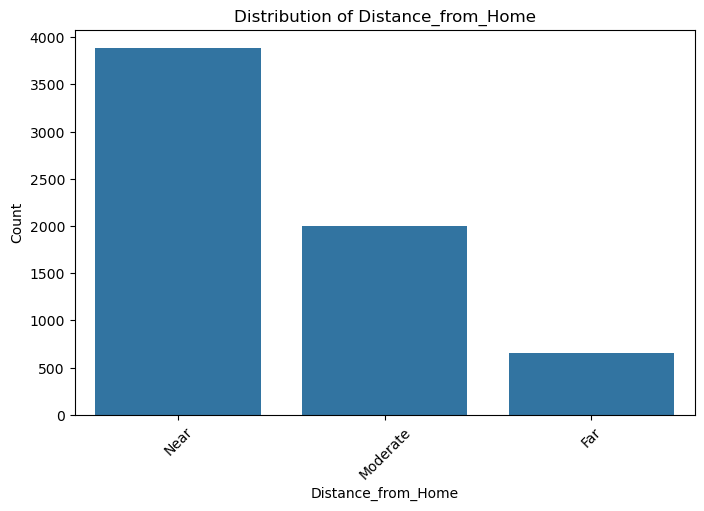

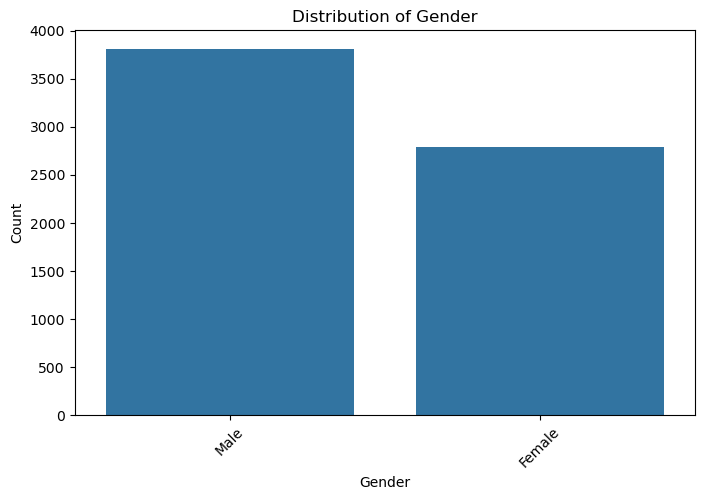

In [98]:
# Categorial variable
categorical_cols = df.select_dtypes(include= ['object']).columns

# loop
for col in categorical_cols:
    
    plt.figure(figsize=(8,5))
    
    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )
    
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    
    plt.xticks(rotation=45)
    
    plt.show()

The category frequency analysis shows that no category is overly represented except 'Internet_Access' variable where 'no' represent less than 8% of the sample.

Exploring numeric variable distribution, skew and outliers


Variable : Hours_Studied
IQR : 8.00
Lower Bound : 4.00
Upper Bound : 36.00
outliers number : 43


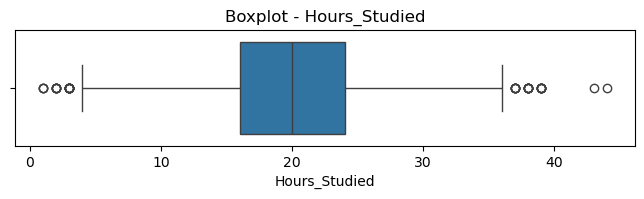


Variable : Attendance
IQR : 20.00
Lower Bound : 40.00
Upper Bound : 120.00
outliers number : 0


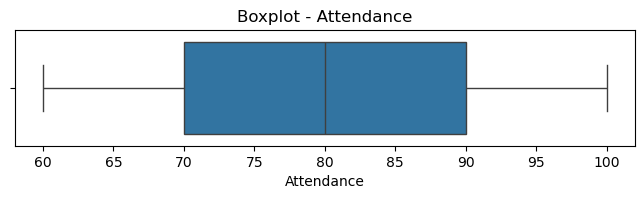


Variable : Sleep_Hours
IQR : 2.00
Lower Bound : 3.00
Upper Bound : 11.00
outliers number : 0


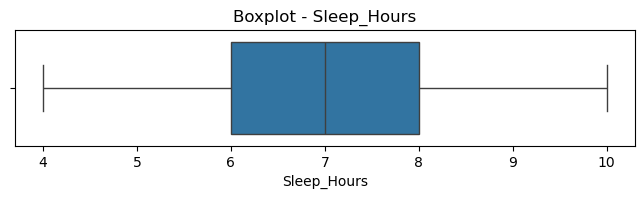


Variable : Previous_Scores
IQR : 25.00
Lower Bound : 25.50
Upper Bound : 125.50
outliers number : 0


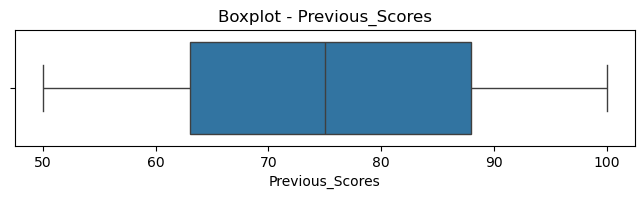


Variable : Tutoring_Sessions
IQR : 1.00
Lower Bound : -0.50
Upper Bound : 3.50
outliers number : 430


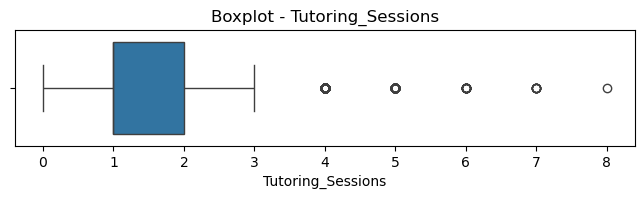


Variable : Physical_Activity
IQR : 2.00
Lower Bound : -1.00
Upper Bound : 7.00
outliers number : 0


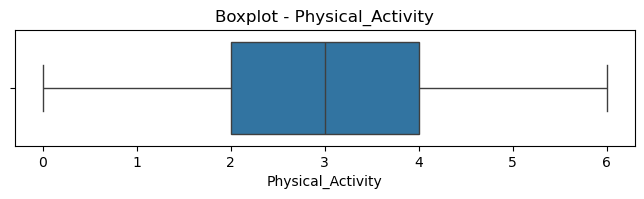


Variable : Exam_Score
IQR : 4.00
Lower Bound : 59.00
Upper Bound : 75.00
outliers number : 104


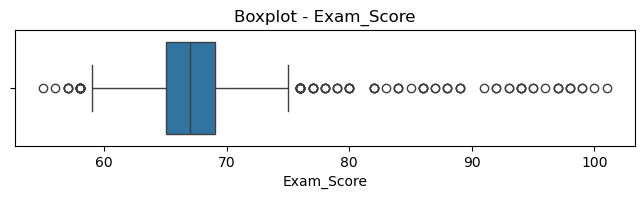

In [93]:
# Select numeric variables
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    
    # -------------------------------
    # Calculed IQR
    # -------------------------------
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Detect outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    # -------------------------------
    # Results
    # -------------------------------
    
    print(f"\nVariable : {col}")
    print(f"IQR : {IQR:.2f}")
    print(f"Lower Bound : {lower_bound:.2f}")
    print(f"Upper Bound : {upper_bound:.2f}")
    print(f"outliers number : {len(outliers)}")
    
    # -------------------------------
    # Boxplot
    # -------------------------------
    
    plt.figure(figsize=(8,1.5))
    
    sns.boxplot(x=df[col])
    
    plt.title(f'Boxplot - {col}')
    
    plt.show()

'Tutoring_Sessions' and 'Exam_Score' are highly right skewed.

<Axes: xlabel='Hours_Studied', ylabel='Exam_Score'>

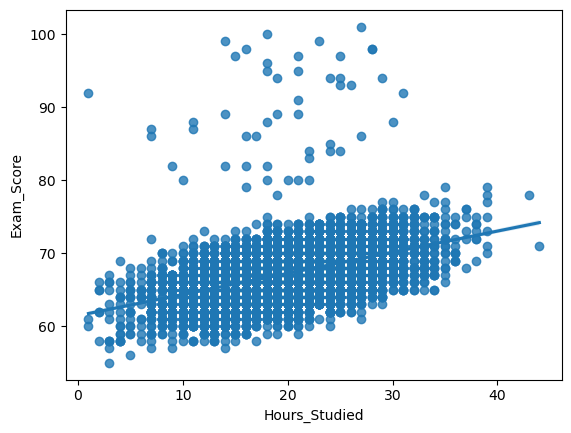

In [66]:
sns.regplot(data=df, x='Hours_Studied', y='Exam_Score')

<Axes: xlabel='Attendance', ylabel='Exam_Score'>

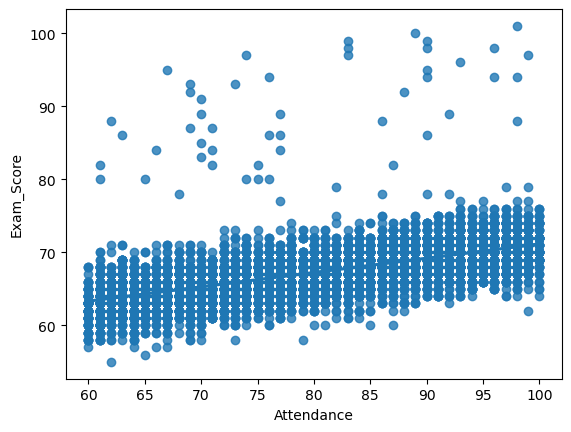

In [67]:
sns.regplot(data=df, x='Attendance', y='Exam_Score')

Correlation analysis was used to evaluate the strength and direction of linear relationships between numerical variables and exam performance.

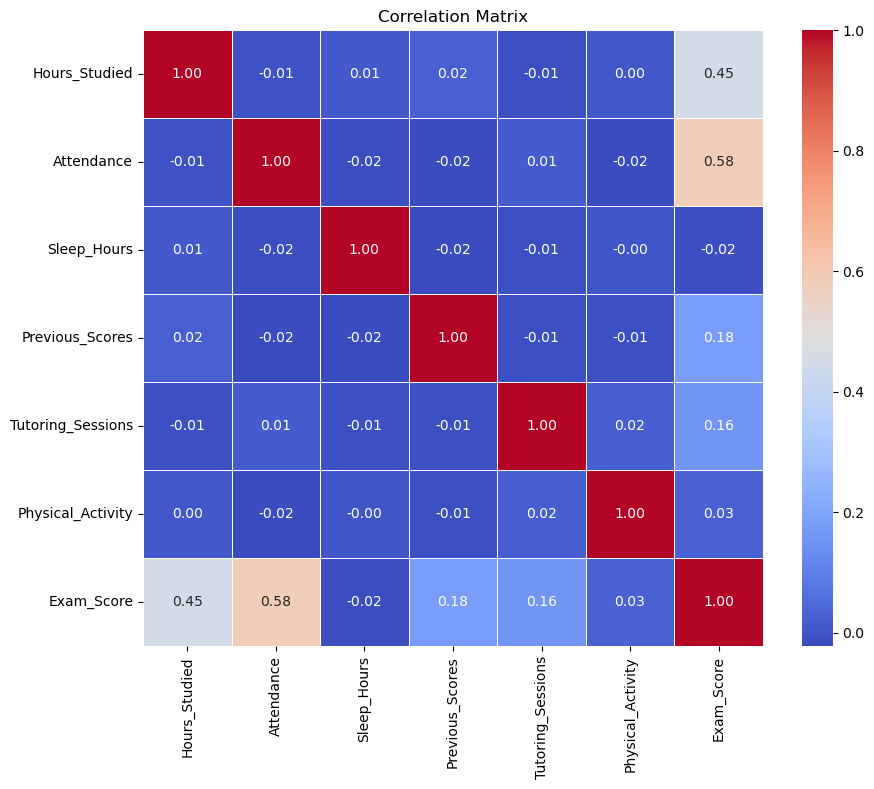

In [32]:
correlation_matrix = df.corr(numeric_only=True)

# Size
plt.figure(figsize=(10,8))

# Heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix')
plt.show()

Attendance and study hours appear positively correlated with exam performance, while sleep hours and physical activity show a weaker relationship. Most correlations remain moderate, suggesting that academic performance is likely influenced by multiple interacting factors rather than a single dominant variable. The correlation between the other variables is rather weak.

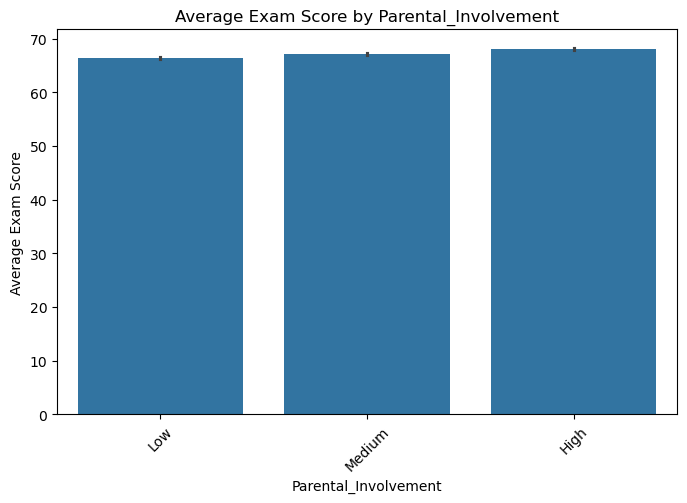

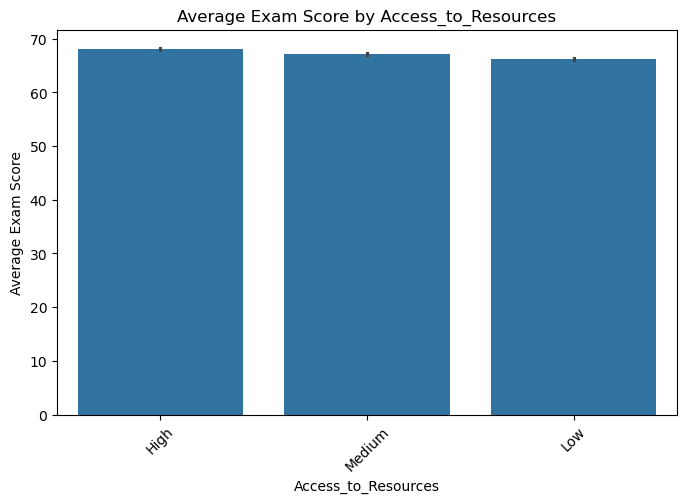

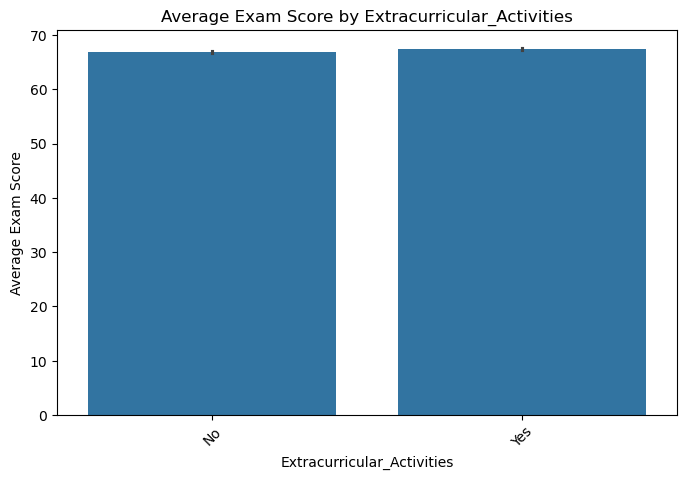

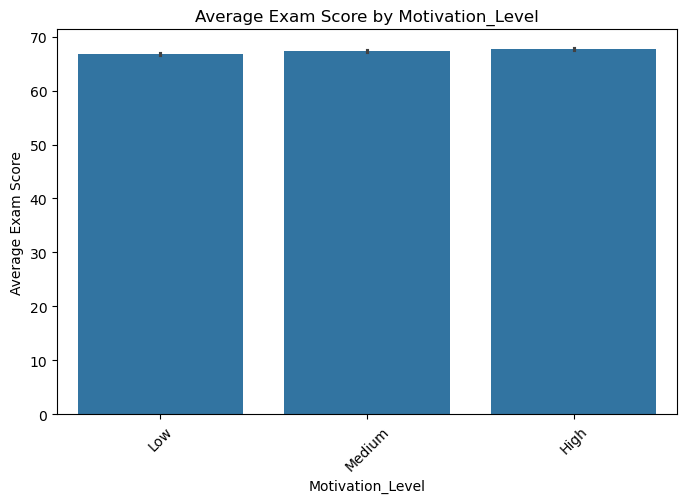

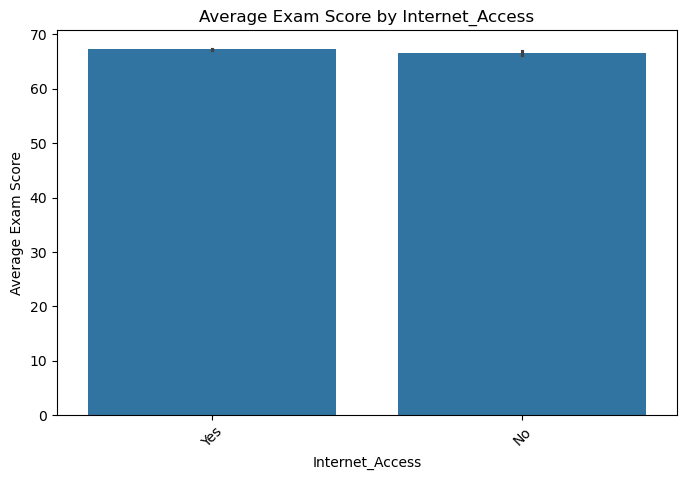

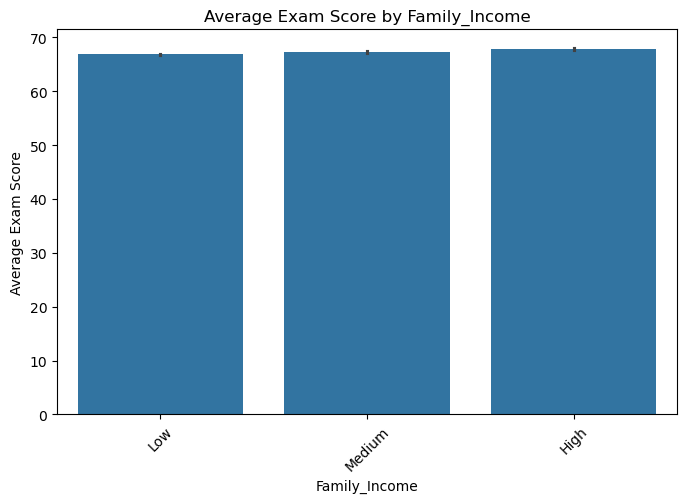

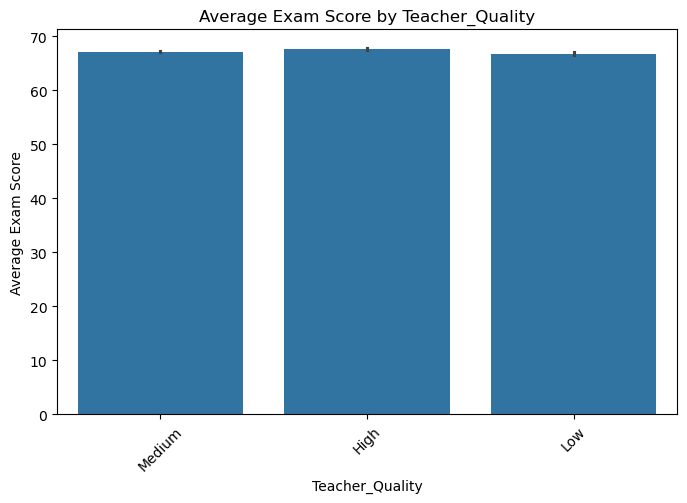

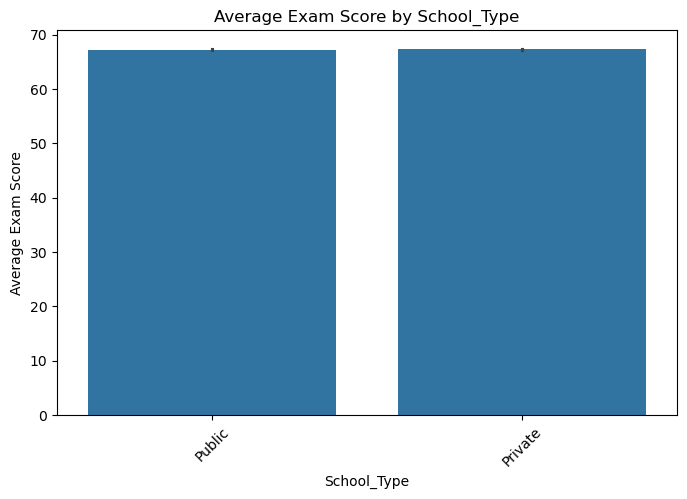

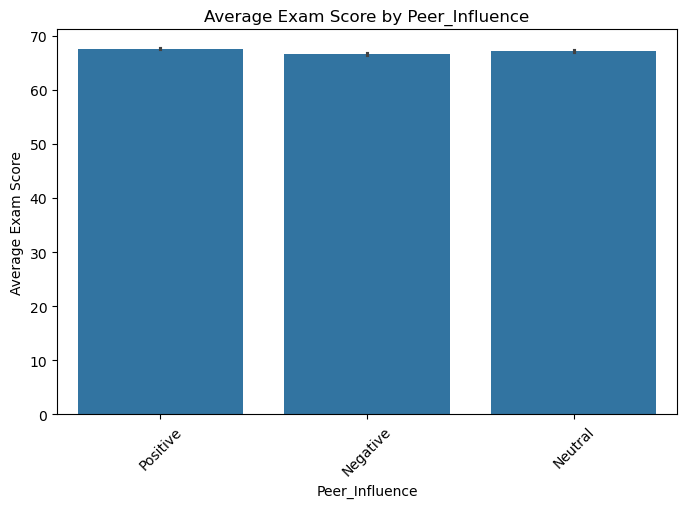

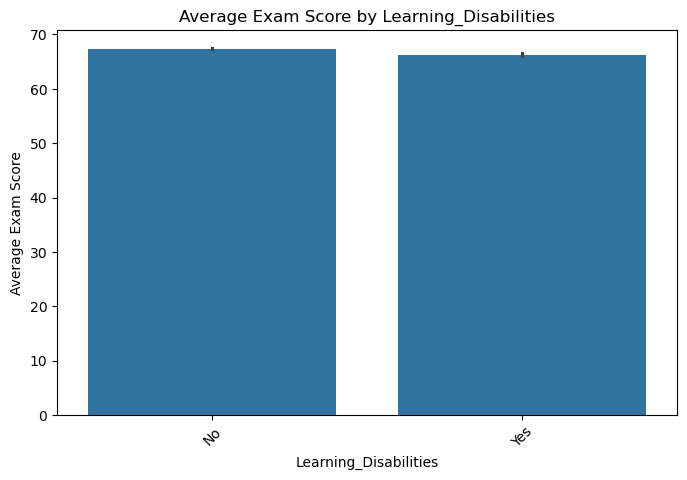

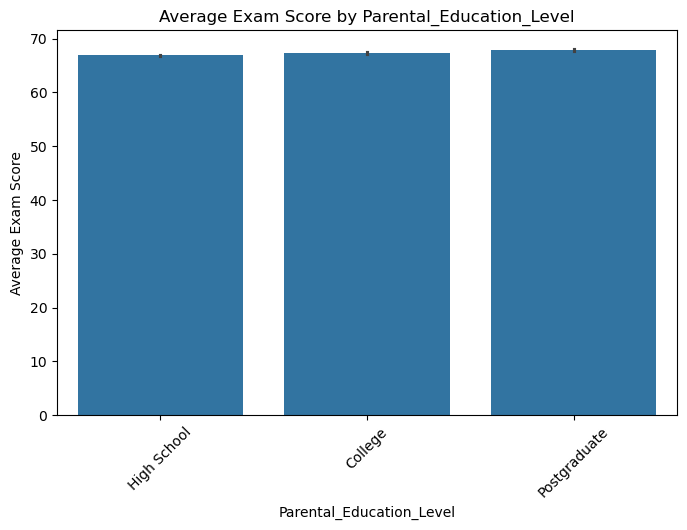

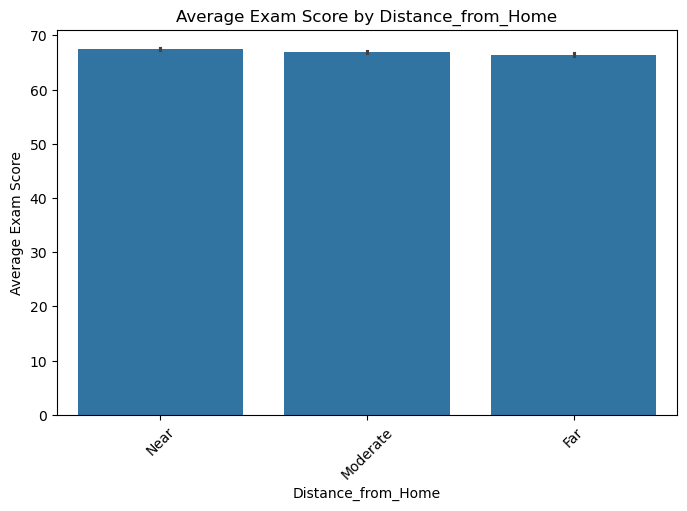

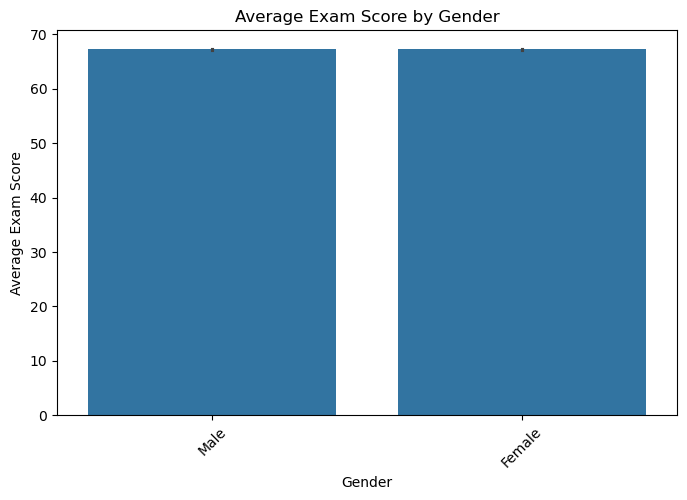

In [42]:

# Categorical Variable 
categorical_cols = df.select_dtypes(include='object').columns

# Loop
for col in categorical_cols:
    
    plt.figure(figsize=(8,5))
    
    sns.barplot(
        data=df,
        x=col,
        y='Exam_Score',
        estimator='mean'
    )
    
    plt.title(f'Average Exam Score by {col}')
    plt.xlabel(col)
    plt.ylabel('Average Exam Score')
    
    plt.xticks(rotation=45)
    
    plt.show()

Most categorical variables do not appear to produce large differences in average exam scores when analyzed independently. This suggests that academic performance may be influenced by multiple interacting factors rather than a single dominant categorical characteristic.

In [69]:
for col in df.select_dtypes(include='object').columns:
    
    print(f"\n===== {col} =====")
    
    print(
        df.groupby(col)['Exam_Score']
        .mean()
        .sort_values(ascending=False)
    )


===== Parental_Involvement =====
Parental_Involvement
High      68.092767
Medium    67.098156
Low       66.358265
Name: Exam_Score, dtype: float64

===== Access_to_Resources =====
Access_to_Resources
High      68.092152
Medium    67.134378
Low       66.203351
Name: Exam_Score, dtype: float64

===== Extracurricular_Activities =====
Extracurricular_Activities
Yes    67.441849
No     66.931435
Name: Exam_Score, dtype: float64

===== Motivation_Level =====
Motivation_Level
High      67.704321
Medium    67.330648
Low       66.752194
Name: Exam_Score, dtype: float64

===== Internet_Access =====
Internet_Access
Yes    67.292895
No     66.535070
Name: Exam_Score, dtype: float64

===== Family_Income =====
Family_Income
High      67.842396
Medium    67.334959
Low       66.848428
Name: Exam_Score, dtype: float64

===== Teacher_Quality =====
Teacher_Quality
High      67.676939
Medium    67.109299
Low       66.753425
Name: Exam_Score, dtype: float64

===== School_Type =====
School_Type
Private    

## ANOVA

ANOVA tests were used to determine whether mean exam scores differed significantly across categorical groups such as motivation level, parental involvement, and access to educational resources. 

In [65]:
# Categorical Variable 
categorical_cols = df.select_dtypes(include='object').columns

# Results
anova_results = []

# Loop
for col in categorical_cols:
    
    # Group Creation
    groups = [
        df[df[col] == category]['Exam_Score']
        for category in df[col].dropna().unique()
    ]
    
    # ANOVA
    f_stat, p_value = f_oneway(*groups)
    
    # Stored results
    anova_results.append({
        'Variable': col,
        'F-Statistic': round(f_stat, 4),
        'P-Value': p_value
    })

# DataFrame result creation
anova_df = pd.DataFrame(anova_results)

# sorted p-value
anova_df = anova_df.sort_values(by='P-Value')

# Display
anova_df

,Variable,F-Statistic,P-Value
1,Access_to_Resources,98.0044,1.139299e-42
0,Parental_Involvement,84.4877,5.875479e-37
10,Parental_Education_Level,36.4272,1.852183e-16
8,Peer_Influence,34.0521,1.936891e-15
5,Family_Income,29.7939,1.314369e-13
11,Distance_from_Home,27.3593,1.470541e-12
9,Learning_Disabilities,48.1434,4.338624e-12
3,Motivation_Level,25.7168,7.492319e-12
6,Teacher_Quality,19.6394,3.135429e-09
2,Extracurricular_Activities,27.4917,1.626678e-07


Most categorical variables were found to be statistically significant predictors of exam performance, although the magnitude of the observed differences often appeared moderate visually.

Socio-economic and environmental variables such as access to resources, parental involvement, and family income showed particularly strong statistical relationships with academic outcomes.

Conversely, variables such as gender and school type did not appear significantly associated with exam performance in this dataset.

## Multivariable analysis

In [79]:
candidate_variables = [
    'Hours_Studied',
    'Attendance',
    'Previous_Scores',
    'Tutoring_Sessions',
    'Motivation_Level',
    'Parental_Involvement',
    'Access_to_Resources',
    'Family_Income',
    'Teacher_Quality',
    'Internet_Access'
]

Multiple linear regression was used to evaluate the combined effect of explanatory variables on exam performance while controlling for other factors.

Forward stepwise selection using AIC was performed to identify the variables contributing most meaningfully to the model.

In [80]:
remaining = candidate_variables.copy()
selected = []

current_aic = float('inf')

while remaining:
    
    results = []
    
    for candidate in remaining:
        
        formula = 'Exam_Score ~ ' + ' + '.join(selected + [candidate])
        
        model = smf.ols(formula, data=df).fit()
        
        results.append((model.aic, candidate))
    
    results.sort()
    
    best_new_aic, best_candidate = results[0]
    
    if best_new_aic < current_aic:
        
        remaining.remove(best_candidate)
        selected.append(best_candidate)
        
        current_aic = best_new_aic
        
        print(f'Added: {best_candidate} | AIC: {current_aic}')
    
    else:
        break

Added: Attendance | AIC: 33982.647833928306
Added: Hours_Studied  | AIC: 31557.817336107364
Added: Access_to_Resources | AIC: 31082.641154412275
Added: Parental_Involvement | AIC: 30593.71169633203
Added: Previous_Scores | AIC: 30064.049403997065
Added: Tutoring_Sessions | AIC: 29591.00578432226
Added: Teacher_Quality | AIC: 29189.48098845152
Added: Family_Income | AIC: 28984.340291809916
Added: Motivation_Level | AIC: 28800.978759569014
Added: Internet_Access | AIC: 28729.62466527432


In [81]:
final_formula = 'Exam_Score ~ ' + ' + '.join(selected)

final_model = smf.ols(final_formula, data=df).fit()

print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.688
Model:                            OLS   Adj. R-squared:                  0.687
Method:                 Least Squares   F-statistic:                     957.3
Date:                Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                        06:53:59   Log-Likelihood:                -14349.
No. Observations:                6529   AIC:                         2.873e+04
Df Residuals:                    6513   BIC:                         2.884e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

The final model explained approximately 69% of the variance in exam scores.

Attendance, previous scores, tutoring sessions, and access to educational resources remained among the strongest predictors after controlling for other variables.

In [82]:


#  Predicor variables
X = final_model.model.exog

# variable name
variable_names = final_model.model.exog_names

# Calculed VIF
vif_data = pd.DataFrame()

vif_data['Variable'] = variable_names
vif_data['VIF'] = [
    variance_inflation_factor(X, i)
    for i in range(X.shape[1])
]

vif_data


,Variable,VIF
0,Intercept,117.628997
1,Access_to_Resources[T.Low],1.339649
2,Access_to_Resources[T.Medium],1.336845
3,Parental_Involvement[T.Low],1.361766
4,Parental_Involvement[T.Medium],1.358030
5,Teacher_Quality[T.Low],1.206095
6,Teacher_Quality[T.Medium],1.204343
7,Family_Income[T.Low],1.850587
8,Family_Income[T.Medium],1.850723
9,Motivation_Level[T.Low],1.746308


Variance Inflation Factor (VIF) diagnostics were performed to assess potential multicollinearity among explanatory variables.

# Conclusion

This analysis suggests that academic performance is influenced by a combination of academic engagement, socio-economic conditions, and educational support factors.

Attendance, study habits, previous academic performance, and access to educational resources appeared among the strongest contributors to exam outcomes.

The project also demonstrated the importance of combining exploratory analysis with inferential statistics and multivariate modeling to better understand complex educational outcomes.

## Potential Improvements

Several methodological improvements could be explored in future iterations of this analysis.

The variable selection process relied primarily on forward and backward stepwise selection using AIC criteria. Although these approaches provide interpretable and computationally efficient models, alternative selection techniques could also be considered and compared.

Potential extensions include:

- ### Backward Selection Comparison
Comparing forward and backward selection results could help evaluate the stability and consistency of the selected variables.
- ### Lasso Regression (L1 Regularization)
Lasso regression could provide an alternative variable selection framework by automatically shrinking less informative coefficients toward zero   while reducing model complexity.
- ### Interaction Effects
 Additional analysis could explore interaction effects between variables such as motivation level and study hours or family income and access to resources.
- ### Residual Diagnostics
Further residual analysis could help evaluate assumptions related to linearity, homoscedasticity, and normality of errors.
- ### Non-Linear Modeling Approaches
More advanced modeling approaches could be explored to capture potential non-linear relationships between explanatory variables and exam performance.

These extensions could provide additional insights into the robustness and interpretability of the statistical conclusions presented in this project.